try to visualize the effect of noise model

In [1]:
import numpy as np
import torch
from experiments_utils import *

ModuleNotFoundError: No module named 'experiments_utils'

In [28]:
CURRENT_BOUNDS = (0.01, 1.5)
EPSILON = 1

REF_I_1 = 0.8218
REF_I_3 = 1.0430
REF_I = [REF_I_1, REF_I_3]

# parameter setting
N_RUNS_A = 100
A_BEAMLINE_LEN = 10

METHODS_A = [
    ("Nelder-Mead", None),
    ("L-BFGS-B", "2-point"),
    ("SLSQP", "2-point"),
    ("COBYLA", None),
    ("trust-constr", "2-point"),
]

A_VARS = {
    1: ["I", "current", lambda x: x],
    3: ["I2", "current", lambda x: x],
}
A_OBJ = {
    8: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
    9: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
}

In [29]:
# this is default version
METHOD_OPTIONS = {
    "L-BFGS-B": {
        "maxcor": 10,
        "ftol": 2.220446049250313e-09,
        "gtol": 1e-5,
        "eps": 1e-8,
        "maxfun": 15000,
        "maxiter": 15000,
        "maxls": 20,
    },
    "SLSQP": {
        "maxiter": 100,
        "ftol": 1e-6,
        "iprint": 1,
        "disp": False,
        "eps": 1.4901161193847656e-08,
        "finite_diff_rel_step": None,
        "workers": None,
    },
    "trust-constr": {
        "xtol": 1e-8,
        "gtol": 1e-8,
        "barrier_tol": 1e-8,
        "sparse_jacobian": None,
        "maxiter": 1000,
        "verbose": 0,
        "finite_diff_rel_step": None,
        "initial_constr_penalty": 1.0,
        "initial_tr_radius": 1.0,
        "initial_barrier_parameter": 0.1,
        "initial_barrier_tolerance": 0.1,
        "factorization_method": None,
        "disp": False,
        "workers": None,
    },
    "Nelder-Mead": {
        "maxiter": None,
        "maxfev": None,
        "disp": False,
        "return_all": False,
        "initial_simplex": None,
        "xatol": 1e-4,
        "fatol": 1e-4,
        "adaptive": False,
    },
    "COBYLA": {
        "rhobeg": 1.0,
        "tol": 1e-4,
        "maxiter": 1000,
        "disp": 0,
        "catol": None,
        "f_target": float("-inf"),
    },
}
use_log = False
log_epsilon = 1e-12

use_log: False
use noise: False

▶ Scenario A — Nelder-Mead  (100 runs)
  Nelder-Mead             run 1/100  MSE=2.638e-09  nit=41  nfev=80   t=21.43s
  Nelder-Mead             run 2/100  MSE=6.145e-09  nit=41  nfev=78   t=19.09s
  Nelder-Mead             run 3/100  MSE=2.297e-09  nit=50  nfev=97   t=20.13s
  Nelder-Mead             run 4/100  MSE=4.368e-08  nit=28  nfev=55   t=11.00s
  Nelder-Mead             run 5/100  MSE=6.624e-09  nit=44  nfev=82   t=17.66s
  Nelder-Mead             run 6/100  MSE=3.857e-08  nit=31  nfev=61   t=14.20s
  Nelder-Mead             run 7/100  MSE=4.297e-08  nit=44  nfev=84   t=16.63s
  Nelder-Mead             run 8/100  MSE=4.360e-09  nit=50  nfev=96   t=22.79s
  Nelder-Mead             run 9/100  MSE=1.184e-08  nit=49  nfev=92   t=18.29s
  Nelder-Mead             run 10/100  MSE=3.064e-09  nit=49  nfev=91   t=17.93s
  Nelder-Mead             run 11/100  MSE=6.611e-09  nit=38  nfev=75   t=15.38s
  Nelder-Mead             run 12/100  MSE=5.340e-09  nit=

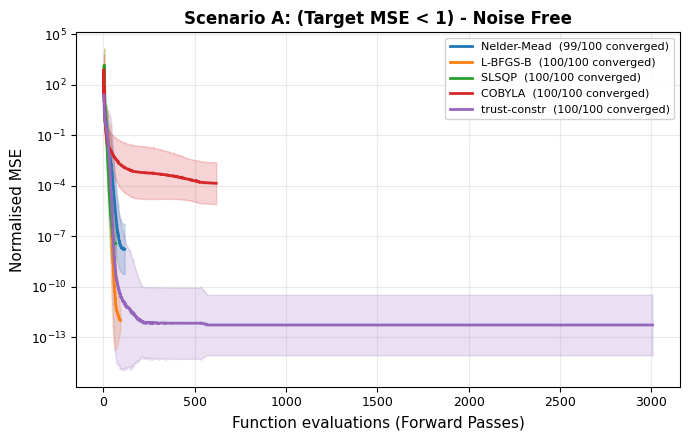

✓ experiment results saved to ../../results/scenario_A_results.pkl
✓ experiment results loaded from ../../results/scenario_A_results.pkl
─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            4.1996e-10     0.9360     1.1792
  L-BFGS-B               4.0367e-15     0.7469     0.5819
  SLSQP                  2.6862e-11     0.2875     0.2752
  COBYLA                 6.4030e-07     0.7467     0.5817
  trust-constr           1.7658e-16     0.7469     0.5819

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: trust-constr,  MSE=1.7658e-16
    I=0.74691 A,  I2=0.58186 A


In [30]:
noise = False
sigma = None
results_A, df_A, final_summary = run_scenario_A(CURRENT_BOUNDS, EPSILON, N_RUNS_A, REF_I, A_OBJ, A_VARS,A_BEAMLINE_LEN, METHODS_A, scale="log",METHOD_OPTIONS=METHOD_OPTIONS, use_log=use_log, use_epsilon=log_epsilon, noise=noise, sigma=sigma)
save_results(results_A, df_A, final_summary, f"../../results/scenario_A_results.pkl")
results_A, df_A, final_summary = load_results(f"../../results/scenario_A_results.pkl")
display_results(results_A, REF_I)
mse_without_noise={}
for m, _ in METHODS_A:
    mse_without_noise[m]=results_A[m][0]["final_mse"]

Demo to use the noise function:

Gaussian noise has been implemented with mean 0 and standard deviation $\sigma$.
The noise can be included by adding the argument `noise` as `True` and `sigma` as the standard deviation of the noise, from the function `run_scenario_A`.

use_log: False
use noise: True
noise standard deviation: 1e-08

▶ Scenario A — Nelder-Mead  (100 runs)
  Nelder-Mead             run 1/100  MSE=2.619e-09  nit=41  nfev=80   t=16.06s
  Nelder-Mead             run 2/100  MSE=6.183e-09  nit=41  nfev=78   t=16.01s
  Nelder-Mead             run 3/100  MSE=2.298e-09  nit=50  nfev=97   t=22.50s
  Nelder-Mead             run 4/100  MSE=4.365e-08  nit=28  nfev=55   t=12.58s
  Nelder-Mead             run 5/100  MSE=6.620e-09  nit=44  nfev=82   t=18.28s
  Nelder-Mead             run 6/100  MSE=3.858e-08  nit=31  nfev=61   t=14.20s
  Nelder-Mead             run 7/100  MSE=4.296e-08  nit=44  nfev=84   t=20.24s
  Nelder-Mead             run 8/100  MSE=4.371e-09  nit=50  nfev=96   t=23.28s
  Nelder-Mead             run 9/100  MSE=1.185e-08  nit=49  nfev=92   t=22.55s
  Nelder-Mead             run 10/100  MSE=3.061e-09  nit=49  nfev=91   t=20.20s
  Nelder-Mead             run 11/100  MSE=6.611e-09  nit=38  nfev=75   t=22.26s
  Nelder-Mead             

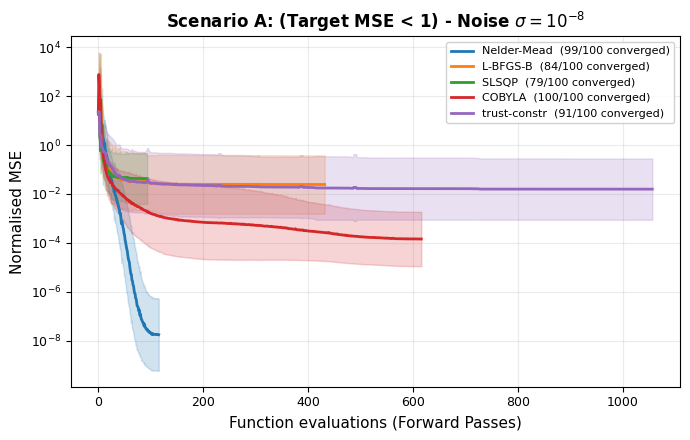

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            4.1800e-10     0.9360     1.1792
  L-BFGS-B               6.8026e-06     0.8694     1.1424
  SLSQP                  1.3097e-05     0.7460     0.5815
  COBYLA                 2.4960e-07     0.7470     0.5819
  trust-constr           7.8134e-07     0.7467     0.5817

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=4.1800e-10
    I=0.93599 A,  I2=1.17920 A
✓ experiment results saved to ../../results/scenario_A_results_sigma_1e-08.pkl
use_log: False
use noise: True
noise standard deviation: 1e-06

▶ Scenario A — Nelder-Mead  (100 runs)
  Nelder-Mead             run 1/100  MSE=2.001e-09  nit=41  nfev=80   t=16.54s
  Nelder-Mead             run 2/100  MSE=7.475e-09  nit=41  nfev=78   t=15.49s
  Nelder-Mead   

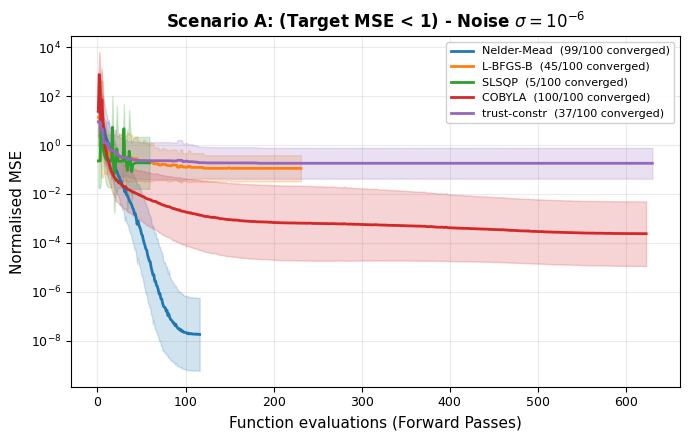

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            1.9697e-10     0.8716     1.1436
  L-BFGS-B               1.4802e-03     0.8519     1.1302
  SLSQP                  1.4547e-03     0.8524     1.1305
  COBYLA                 2.4014e-07     0.7469     0.5818
  trust-constr           2.8557e-03     0.9505     1.1835

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=1.9697e-10
    I=0.87155 A,  I2=1.14361 A
✓ experiment results saved to ../../results/scenario_A_results_sigma_1e-06.pkl
use_log: False
use noise: True
noise standard deviation: 0.0001

▶ Scenario A — Nelder-Mead  (100 runs)
  Nelder-Mead             run 1/100  MSE=7.678e-09  nit=41  nfev=86   t=15.47s
  Nelder-Mead             run 2/100  MSE=5.224e-10  nit=46  nfev=93   t=15.62s
  Nelder-Mead  

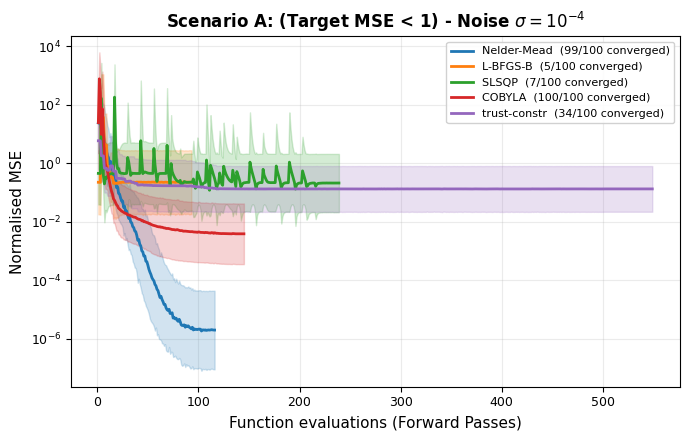

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            5.2238e-10     0.9359     1.1792
  L-BFGS-B               1.4117e-03     0.8519     1.1302
  SLSQP                  1.5777e-03     0.8531     1.1307
  COBYLA                 3.0885e-05     0.9401     1.1812
  trust-constr           4.6911e-04     0.8568     1.1346

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=5.2238e-10
    I=0.93592 A,  I2=1.17919 A
✓ experiment results saved to ../../results/scenario_A_results_sigma_0.0001.pkl
use_log: False
use noise: True
noise standard deviation: 0.01

▶ Scenario A — Nelder-Mead  (100 runs)
  Nelder-Mead             run 1/100  MSE=2.982e-01  nit=152 nfev=400  t=68.20s
  Nelder-Mead             run 2/100  MSE=7.926e-01  nit=149 nfev=400  t=68.09s
  Nelder-Mead   

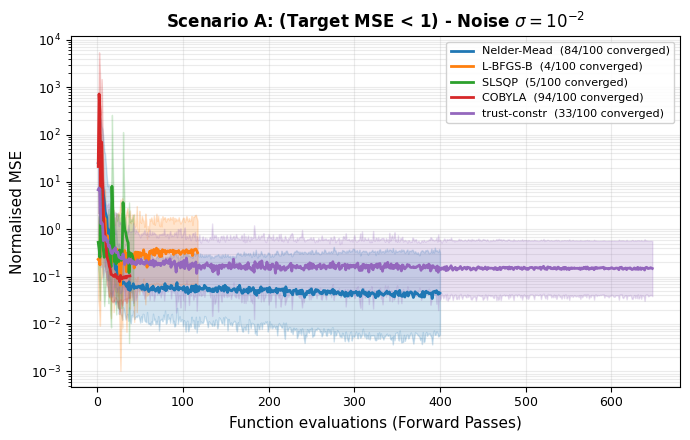

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            1.0376e-06     0.2892     0.2800
  L-BFGS-B               2.8724e-02     0.8519     1.1302
  SLSQP                  1.2975e-02     0.8538     1.1299
  COBYLA                 2.0912e-05     0.8503     1.1368
  trust-constr           2.0539e-03     0.7303     0.5806

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=1.0376e-06
    I=0.28921 A,  I2=0.28005 A
✓ experiment results saved to ../../results/scenario_A_results_sigma_0.01.pkl
use_log: False
use noise: True
noise standard deviation: 1.0

▶ Scenario A — Nelder-Mead  (100 runs)
  Nelder-Mead             run 1/100  MSE=4.530e-03  nit=147 nfev=400  t=76.78s
  Nelder-Mead             run 2/100  MSE=6.693e-02  nit=159 nfev=400  t=78.58s
  Nelder-Mead      

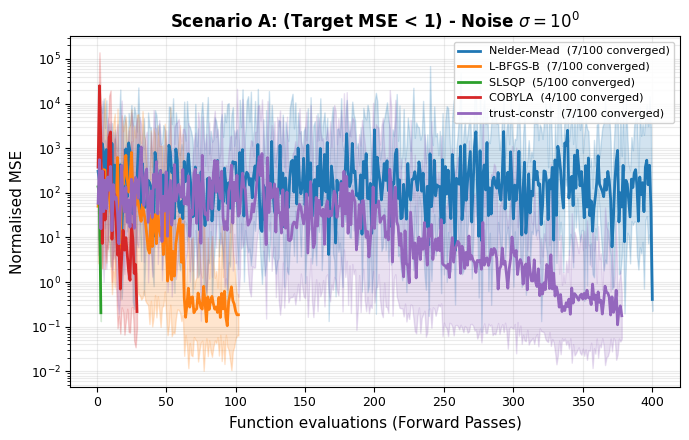

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            7.5624e-05     0.4051     0.7431
  L-BFGS-B               1.5436e+00     0.0228     0.4839
  SLSQP                  3.6393e-02     0.8560     1.0249
  COBYLA                 2.0639e-03     0.2100     0.0100
  trust-constr           9.4053e-02     0.1417     0.8393

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=7.5624e-05
    I=0.40513 A,  I2=0.74307 A
✓ experiment results saved to ../../results/scenario_A_results_sigma_1.0.pkl


In [31]:
mse_with_noise = {}
for m, _ in METHODS_A:
    mse_with_noise[m] = []

noise = True
sigma_set = [1e-8, 1e-6, 1e-4, 1e-2, 1]
for sigma in sigma_set:
    sigma = sigma * torch.ones(26)
    results_A, df_A, final_summary = run_scenario_A(
        CURRENT_BOUNDS,
        EPSILON,
        N_RUNS_A,
        REF_I,
        A_OBJ,
        A_VARS,
        A_BEAMLINE_LEN,
        METHODS_A,
        scale="log",
        METHOD_OPTIONS=METHOD_OPTIONS,
        use_log=use_log,
        use_epsilon=log_epsilon,
        noise=noise,
        sigma=sigma,
    )
    display_results(results_A, REF_I)
    for m, _ in METHODS_A:
        mse_with_noise[m].append((results_A[m][0]["final_mse"], sigma))
    save_results(results_A, df_A, final_summary, f"../../results/scenario_A_results_sigma_{sigma[0].item()}.pkl")

give the plot of mse difference vs sigma for each method

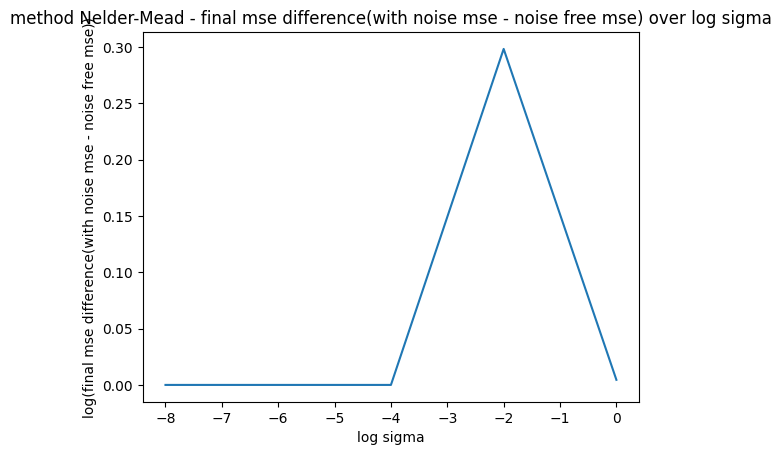

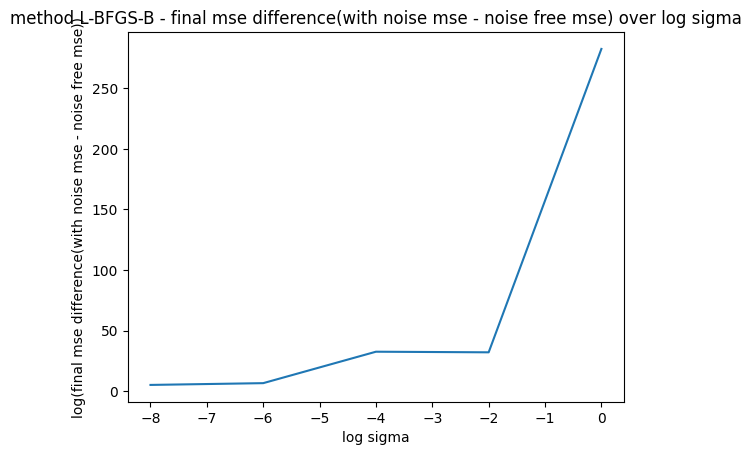

C:\Users\yilu2\AppData\Local\Temp\ipykernel_30992\3494414569.py:9: RuntimeWarning: overflow encountered in exp
  exp_mse_diff=np.exp(mse_diff)


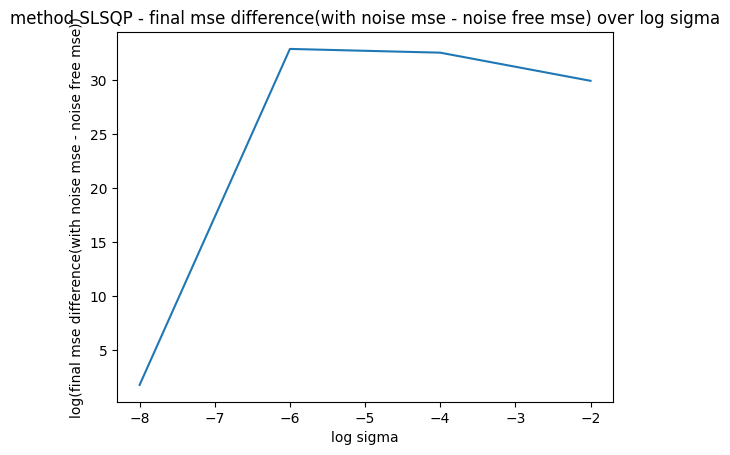

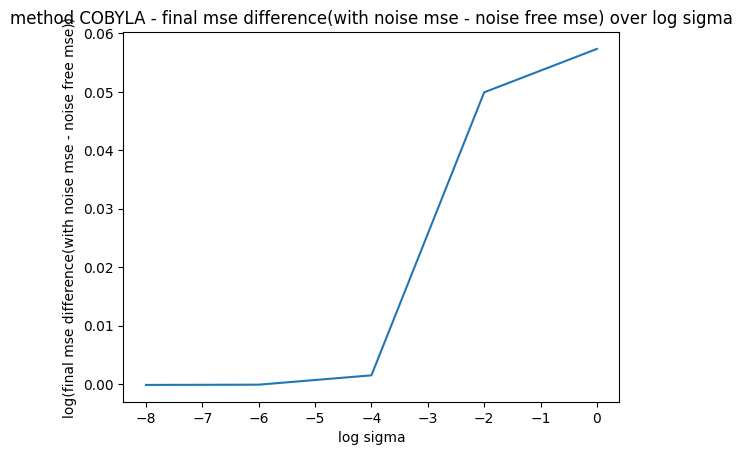

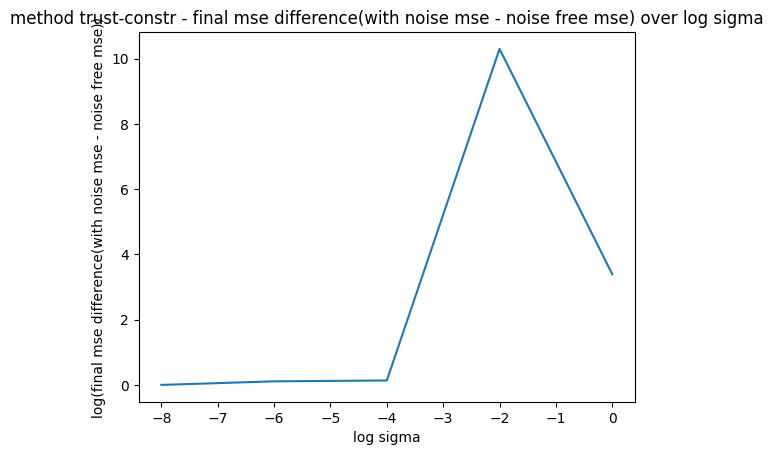

In [32]:
import matplotlib.pyplot as plt

log_sig=np.array([-8,-6, -4, -2, 0])


for m, _ in METHODS_A:

    mse_diff=np.array([i[0]-mse_without_noise[m] for i in mse_with_noise[m]])
    exp_mse_diff=np.exp(mse_diff)
    plt.plot(log_sig, np.log(exp_mse_diff))
    plt.xlabel("log sigma")
    # plt.ylabel("final mse difference(with noise mse - noise free mse)")
    plt.ylabel("log(final mse difference(with noise mse - noise free mse))")
    plt.title(f"method {m} - final mse difference(with noise mse - noise free mse) over log sigma")
    plt.show()

# landscape and corresponding optimizer

In [3]:
import os
CURRENT_DIR = os.getcwd()

import pickle
# load the results

with open(os.path.join(CURRENT_DIR, "../../results/scenario_A_results.pkl"), "rb") as f:    
    data = pickle.load(f)
    df_A = data["df_A"]
    results_A = data["results_A"]
    final_summary = data["final_summary"]

Grid 500 500, MSE range [9.79e-06, 3.41e+03]


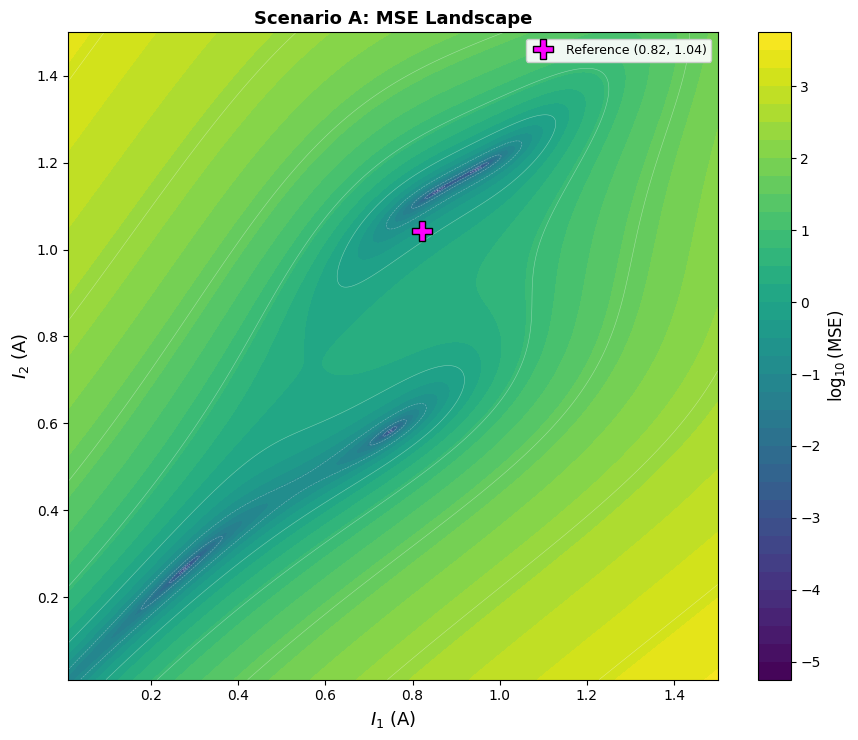

In [4]:
# MSE landscape heatmap

import pickle, os
import numpy as np
import matplotlib.pyplot as plt

with open(os.path.join(CURRENT_DIR, "../../results/scenario_A_landscape.pkl"), "rb") as f:
    L = pickle.load(f)
I1_vals, I2_vals, MSE_grid = L["I1_vals"], L["I2_vals"], L["MSE_grid"]

print(f"Grid {L['N_GRID']} {L['N_GRID']}, MSE range [{np.nanmin(MSE_grid):.2e}, {np.nanmax(MSE_grid):.2e}]")

Z = np.log10(np.maximum(MSE_grid, 1e-16))

fig, ax = plt.subplots(figsize=(9, 7.5))

cf = ax.contourf(I1_vals, I2_vals, Z, levels=40, cmap='viridis')
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r'$\log_{10}(\mathrm{MSE})$', fontsize=12)

ax.contour(I1_vals, I2_vals, Z, levels=12, colors='white', linewidths=0.4, alpha=0.4)

ax.plot(0.8218, 1.0430, 'P', color='magenta', markersize=15,
        markeredgecolor='black', label='Reference (0.82, 1.04)', zorder=11)

traj_path = os.path.join(CURRENT_DIR, "../results/scenario_A_trajectories.pkl")

ax.set_xlabel(r'$I_1$ (A)', fontsize=13)
ax.set_ylabel(r'$I_2$ (A)', fontsize=13)
ax.set_title('Scenario A: MSE Landscape', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right', framealpha=0.92)
ax.set_xlim(I1_vals[0], I1_vals[-1])
ax.set_ylim(I2_vals[0], I2_vals[-1])
fig.tight_layout()
plt.show()

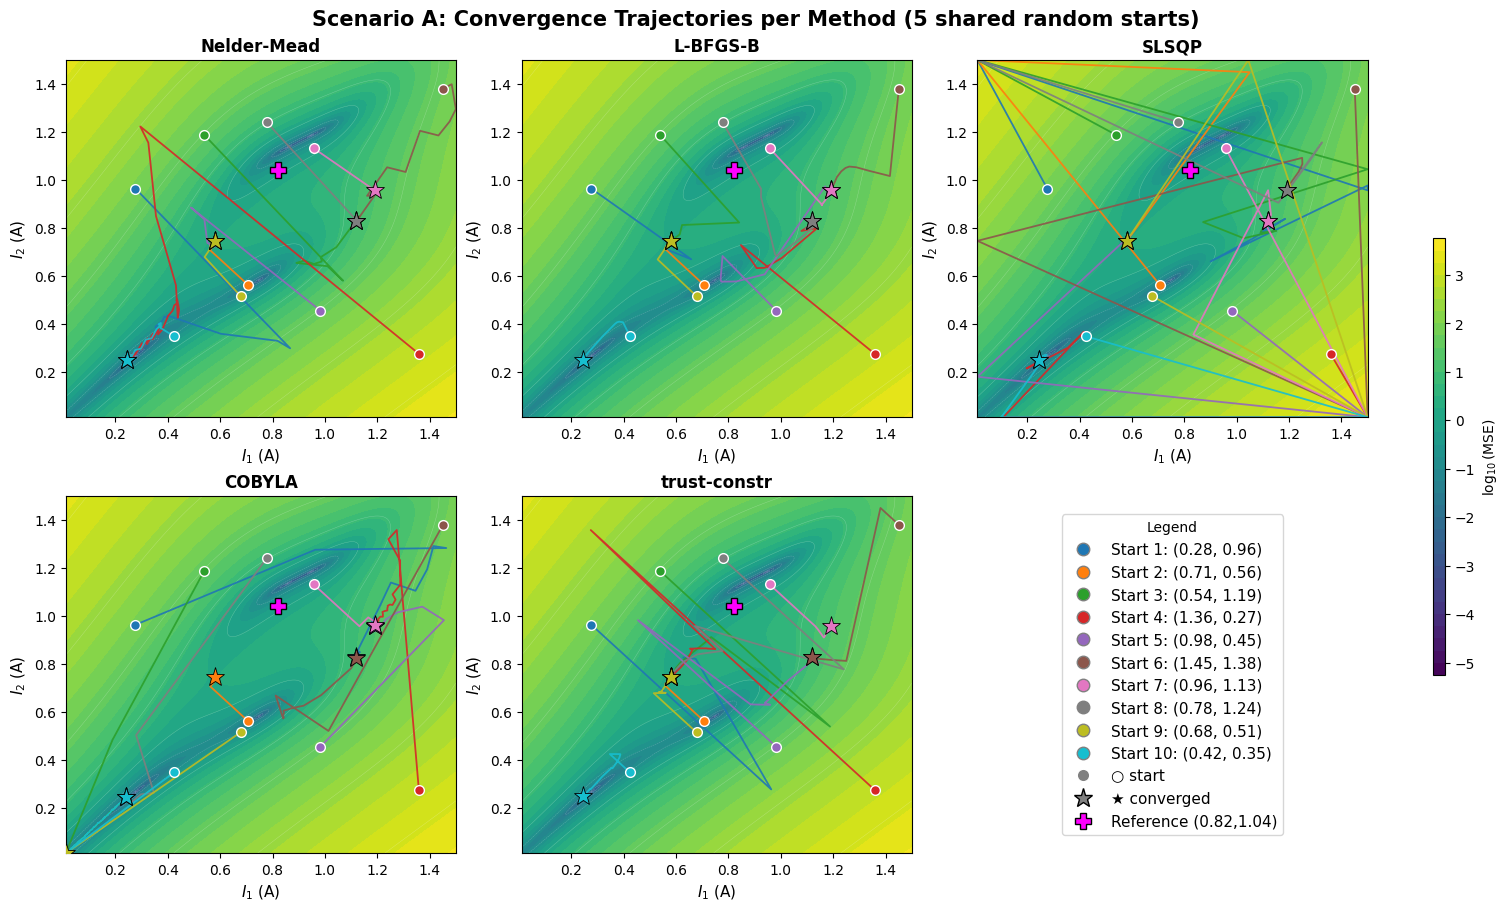

In [5]:
import pickle, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

with open(os.path.join(CURRENT_DIR, "../../results/scenario_A_landscape.pkl"), "rb") as f:
    L = pickle.load(f)
with open(os.path.join(CURRENT_DIR, "../../results/scenario_A_trajectories.pkl"), "rb") as f:
    T = pickle.load(f)

I1_vals, I2_vals, MSE_grid = L["I1_vals"], L["I2_vals"], L["MSE_grid"]
trajectories, STARTS = T["trajectories"], T["starts"]
Z = np.log10(np.maximum(MSE_grid, 1e-16))

methods = list(trajectories.keys())
start_colors = plt.colormaps.get_cmap('tab10')

fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
axes = axes.flatten()

for idx, method in enumerate(methods):
    ax = axes[idx]
    cf = ax.contourf(I1_vals, I2_vals, Z, levels=40, cmap='viridis')
    ax.contour(I1_vals, I2_vals, Z, levels=10, colors='white', linewidths=0.3, alpha=0.3)

    for s_idx, d in enumerate(trajectories[method]):
        path = d["path"]; c = start_colors(s_idx)
        ax.plot(path[:,0], path[:,1], '-', color=c, linewidth=1.3, alpha=0.9)
        ax.plot(path[0,0],  path[0,1],  'o', color=c, ms=7,  mec='white', mew=1.0, zorder=9)    
        ax.plot(path[-1,0], path[-1,1], '*', color=c, ms=14, mec='black', mew=0.6, zorder=10)   

    ax.plot(0.8218, 1.0430, 'P', color='magenta', ms=12, mec='black', zorder=11)   
    ax.set_title(method, fontsize=12, fontweight='bold')
    ax.set_xlabel(r'$I_1$ (A)', fontsize=11); ax.set_ylabel(r'$I_2$ (A)', fontsize=11)
    ax.set_xlim(I1_vals[0], I1_vals[-1]); ax.set_ylim(I2_vals[0], I2_vals[-1])

axes[5].axis('off')
leg = [Line2D([0],[0], marker='o', color='w', markerfacecolor=start_colors(i),
              markeredgecolor='gray', ms=9,
              label=f"Start {i+1}: ({STARTS[i,0]:.2f}, {STARTS[i,1]:.2f})")
       for i in range(len(STARTS))]
leg += [Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', ms=9, label='○ start'),
        Line2D([0],[0], marker='*', color='w', markerfacecolor='gray', markeredgecolor='black', ms=14, label='★ converged'),
        Line2D([0],[0], marker='P', color='w', markerfacecolor='magenta', markeredgecolor='black', ms=12, label='Reference (0.82,1.04)')]
axes[5].legend(handles=leg, loc='center', fontsize=11, frameon=True, title='Legend')

fig.colorbar(cf, ax=list(axes), label=r'$\log_{10}(\mathrm{MSE})$', shrink=0.55, aspect=35)
fig.suptitle('Scenario A: Convergence Trajectories per Method (5 shared random starts)',
             fontsize=15, fontweight='bold')
plt.show()